# KSE-30 Full EDA & Preprocessing
### 29 Stocks + 12 Sector Benchmarks — Complete Pipeline
---
**Pipeline:**
1. Load & Setup
2. EDA — Stocks
3. EDA — Sector Benchmarks
4. EDA — Cross-Dataset (alignment, correlations)
5. Data Cleaning (missing values, OHLC violations, outliers)
6. Feature Engineering (log returns, normalization)
7. Save All Clean Files

## 0. Install & Import

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy -q
print('Done.')

Done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

START_DATE = '2018-01-01'
END_DATE   = '2025-12-31'

SECTOR_MAP = {
    'ABOT.KA':'Pharmaceuticals', 'BAFL.KA':'Banking', 'DGKC.KA':'Cement',
    'EFERT.KA':'Fertilizer', 'FCCL.KA':'Cement', 'FFC.KA':'Fertilizer',
    'HBL.KA':'Banking', 'HUBC.KA':'Power_Generation', 'ICI.KA':'Chemicals',
    'KAPCO.KA':'Power_Generation', 'KEL.KA':'Power_Generation', 'KOHC.KA':'Cement',
    'LUCK.KA':'Cement', 'MARI.KA':'Oil_Gas', 'MCB.KA':'Banking', 'MEBL.KA':'Banking',
    'MLCF.KA':'Cement', 'NBP.KA':'Banking', 'NESTLE.KA':'Food_Beverages',
    'OGDC.KA':'Oil_Gas', 'PKGS.KA':'Paper_Board', 'POL.KA':'Oil_Gas',
    'PPL.KA':'Oil_Gas', 'PSEL.KA':'Financial_Services', 'PSO.KA':'Oil_Gas',
    'SEARL.KA':'Pharmaceuticals', 'SYS.KA':'Technology', 'TRG.KA':'Technology',
    'UBL.KA':'Banking'
}

print('Setup complete.')

Setup complete.


---
## 1. Load All Files

In [3]:
from google.colab import files

print('Upload 4 files:')
print('  1. KSE30_all_stocks_combined.csv')
print('  2. KSE30_sector_benchmarks.csv')
print('  3. KSE30_sector_benchmarks_wide.csv')
print('  4. KSE30_sector_returns.csv')
uploaded = files.upload()

fnames = list(uploaded.keys())

def find_file(keyword):
    for f in fnames:
        if keyword.lower() in f.lower():
            return f
    return None

# Load stocks
stocks_raw = pd.read_csv(find_file('combined'))
stocks_raw['Date'] = pd.to_datetime(stocks_raw['Date'], dayfirst=True)
stocks_raw = stocks_raw[stocks_raw['Ticker'] != 'ENGRO.KA'].reset_index(drop=True)
stocks_raw = stocks_raw.sort_values(['Ticker','Date']).reset_index(drop=True)
stocks_raw['Sector'] = stocks_raw['Ticker'].map(SECTOR_MAP)

# Load benchmarks
bench_long = pd.read_csv(find_file('benchmarks.csv') or find_file('sector_benchmarks.csv'))
bench_long['Date'] = pd.to_datetime(bench_long['Date'])

bench_wide = pd.read_csv(find_file('wide'))
bench_wide['Date'] = pd.to_datetime(bench_wide['Date'])

sect_returns = pd.read_csv(find_file('returns'))
sect_returns['Date'] = pd.to_datetime(sect_returns['Date'])

print(f'Stocks    : {stocks_raw["Ticker"].nunique()} stocks, {len(stocks_raw):,} rows')
print(f'Bench long: {bench_long["Sector"].nunique()} sectors, {len(bench_long):,} rows')
print(f'Bench wide: {bench_wide.shape}')
print(f'Sect ret  : {sect_returns.shape}')

Upload 4 files:
  1. KSE30_all_stocks_combined.csv
  2. KSE30_sector_benchmarks.csv
  3. KSE30_sector_benchmarks_wide.csv
  4. KSE30_sector_returns.csv


Saving KSE30_all_stocks_combined.csv to KSE30_all_stocks_combined.csv
Saving KSE30_sector_benchmarks.csv to KSE30_sector_benchmarks.csv
Saving KSE30_sector_benchmarks_wide.csv to KSE30_sector_benchmarks_wide.csv
Saving KSE30_sector_returns.csv to KSE30_sector_returns.csv
Stocks    : 29 stocks, 59,905 rows
Bench long: 12 sectors, 24,755 rows
Bench wide: (2074, 13)
Sect ret  : (1991, 13)


---
## 2. EDA — Individual Stocks

=== Missing Values — Stocks ===
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
Name      0
Sector    0
dtype: int64


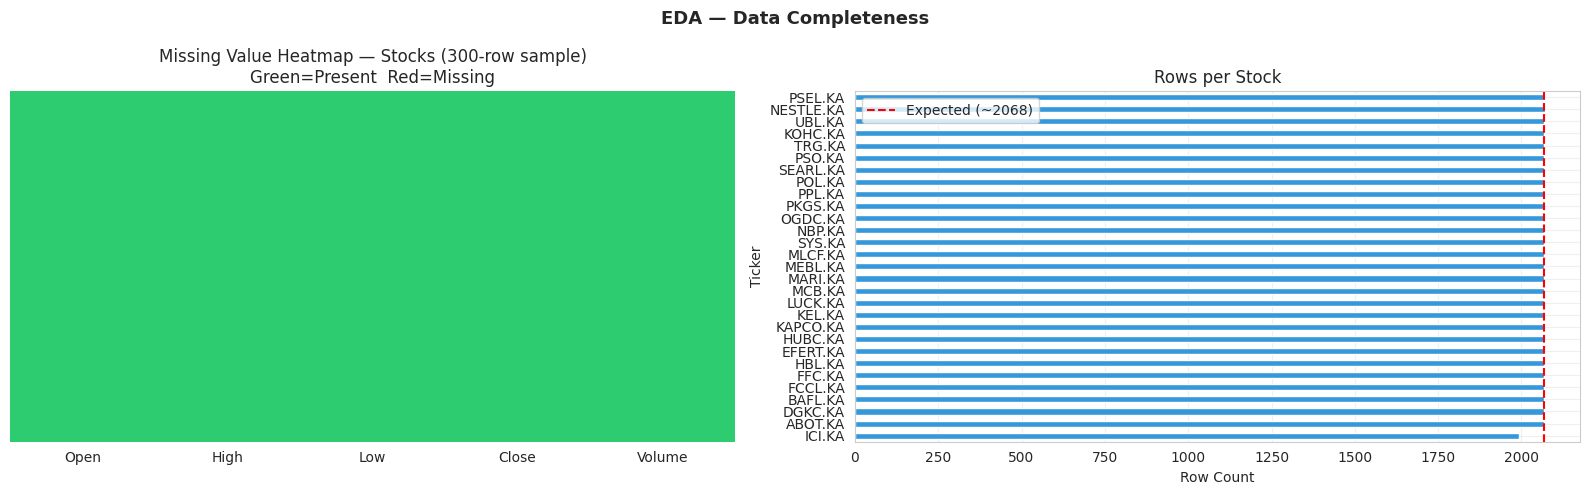

In [4]:
# ── 2.1 Missing Value Summary ────────────────────────────────────────────────
print('=== Missing Values — Stocks ===')
print(stocks_raw.isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap sample
sample = stocks_raw[['Open','High','Low','Close','Volume']].sample(300, random_state=42)
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Missing Value Heatmap — Stocks (300-row sample)\nGreen=Present  Red=Missing')

# Per-stock row counts
row_counts = stocks_raw.groupby('Ticker').size().sort_values()
row_counts.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].axvline(2068, color='red', linestyle='--', label='Expected (~2068)')
axes[1].set_title('Rows per Stock')
axes[1].set_xlabel('Row Count')
axes[1].legend()

plt.suptitle('EDA — Data Completeness', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

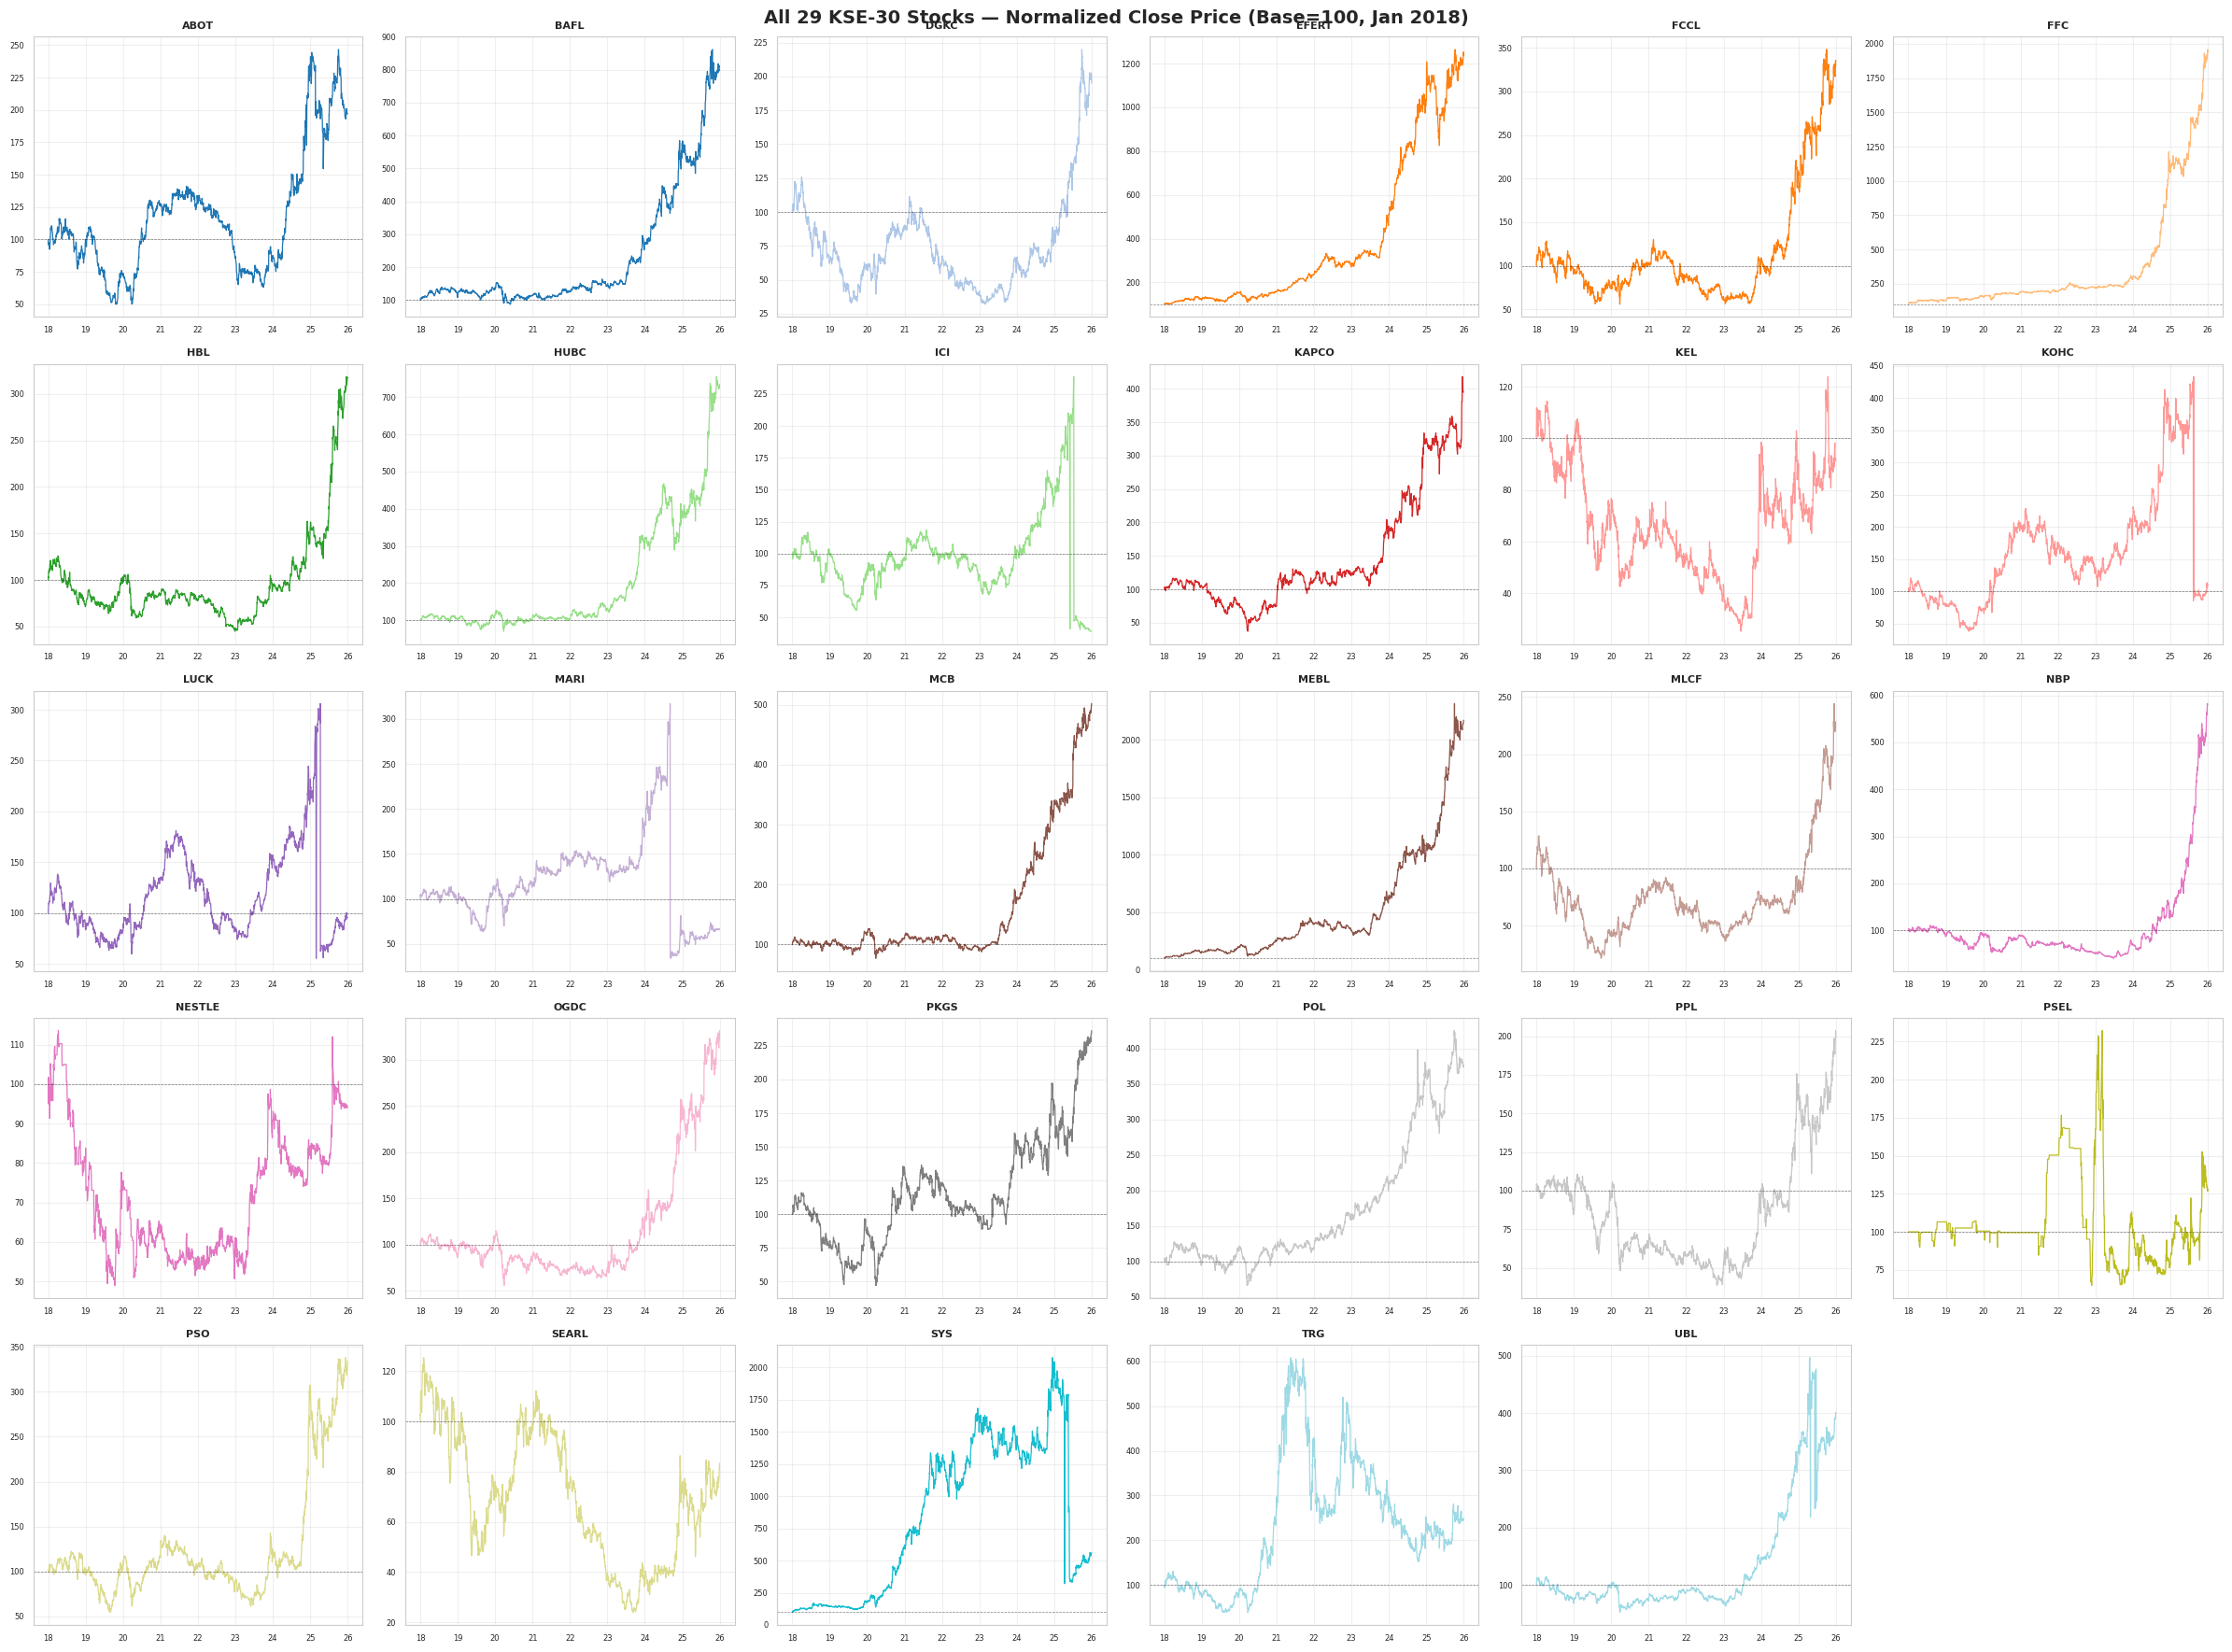

In [5]:
# ── 2.2 Normalized Price Trends — All 29 Stocks ───────────────────────────────
fig, axes = plt.subplots(5, 6, figsize=(24, 18))
axes = axes.flatten()

tickers = sorted(stocks_raw['Ticker'].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(tickers)))

for i, ticker in enumerate(tickers):
    grp = stocks_raw[stocks_raw['Ticker'] == ticker].sort_values('Date')
    norm = grp['Close'] / grp['Close'].iloc[0] * 100
    axes[i].plot(grp['Date'], norm, color=colors[i], linewidth=0.9)
    axes[i].axhline(100, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    axes[i].set_title(ticker.replace('.KA',''), fontsize=8, fontweight='bold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%y'))
    axes[i].tick_params(labelsize=6)

# Hide unused
for j in range(len(tickers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('All 29 KSE-30 Stocks — Normalized Close Price (Base=100, Jan 2018)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

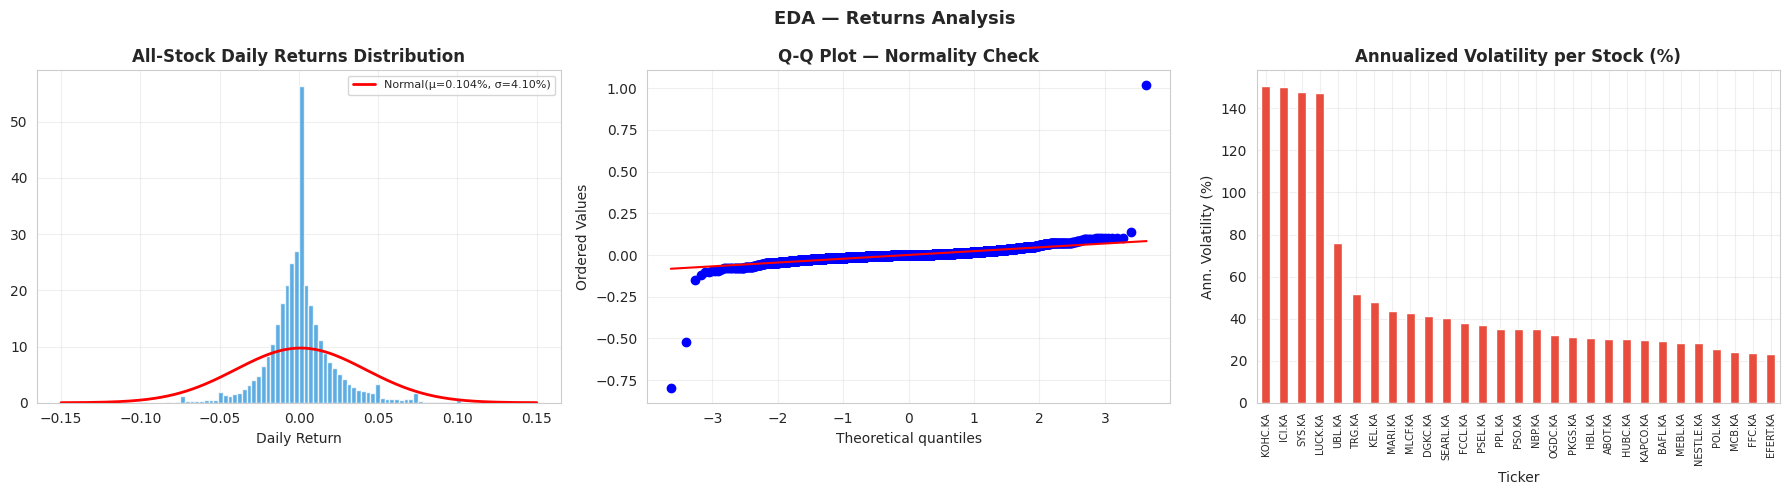

Shapiro-Wilk: stat=0.5961, p=1.32e-75 → Returns are NOT normally distributed (fat tails expected)
Skewness: 60.4444
Kurtosis: 5941.1809


In [6]:
# ── 2.3 Daily Returns Distribution ───────────────────────────────────────────
stocks_raw['Return'] = stocks_raw.groupby('Ticker')['Close'].pct_change()
all_returns = stocks_raw['Return'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(all_returns.clip(-0.15, 0.15), bins=100,
             density=True, color='#3498db', edgecolor='white', alpha=0.8)
mu, sigma = all_returns.mean(), all_returns.std()
x = np.linspace(-0.15, 0.15, 300)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2,
             label=f'Normal(μ={mu*100:.3f}%, σ={sigma*100:.2f}%)')
axes[0].set_title('All-Stock Daily Returns Distribution', fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].legend(fontsize=8)

# Q-Q plot
sample_ret = all_returns.dropna().sample(5000, random_state=42)
stats.probplot(sample_ret, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — Normality Check', fontweight='bold')

# Per-stock return volatility
vol_per_stock = stocks_raw.groupby('Ticker')['Return'].std() * np.sqrt(252) * 100
vol_per_stock = vol_per_stock.sort_values(ascending=False)
vol_per_stock.plot(kind='bar', ax=axes[2], color='#e74c3c', edgecolor='white')
axes[2].set_title('Annualized Volatility per Stock (%)', fontweight='bold')
axes[2].set_ylabel('Ann. Volatility (%)')
axes[2].tick_params(axis='x', rotation=90, labelsize=7)

plt.suptitle('EDA — Returns Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

stat, p = stats.shapiro(sample_ret)
print(f'Shapiro-Wilk: stat={stat:.4f}, p={p:.2e} → Returns are NOT normally distributed (fat tails expected)')
print(f'Skewness: {all_returns.skew():.4f}')
print(f'Kurtosis: {all_returns.kurtosis():.4f}')

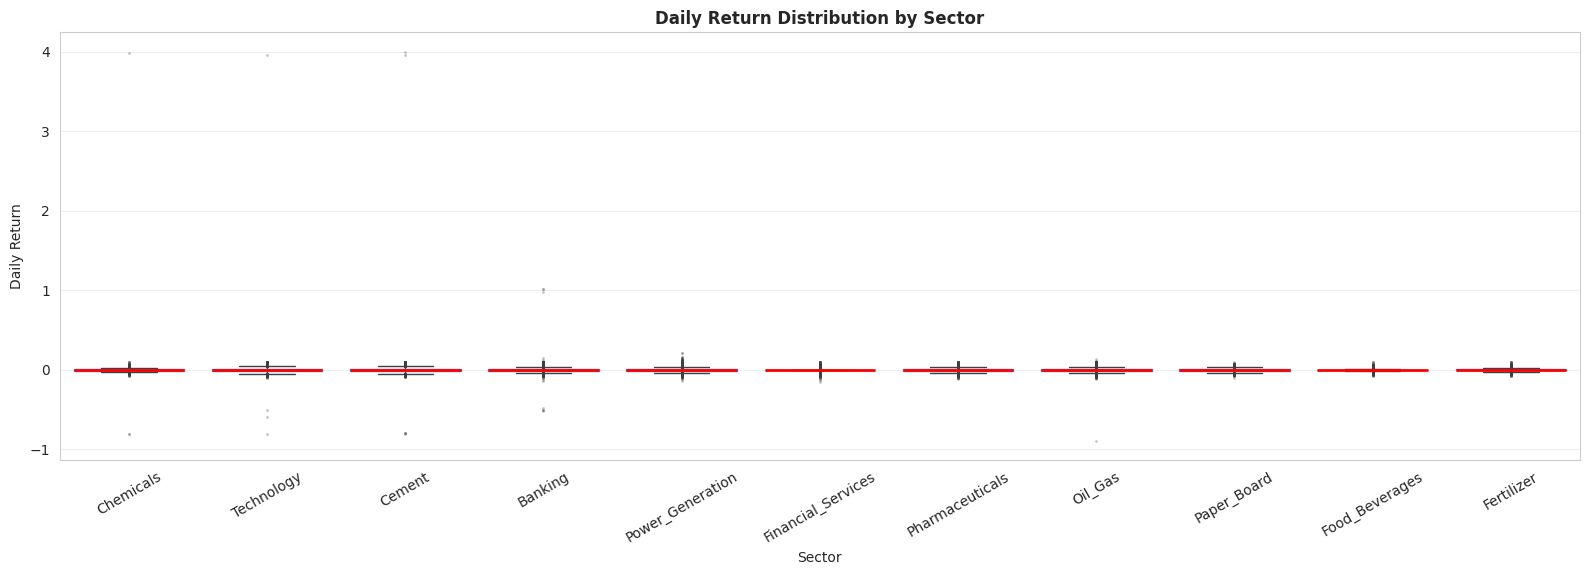

In [8]:
import seaborn as sns
# ── 2.4 Returns Distribution by Sector ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
sector_order = stocks_raw.groupby('Sector')['Return'].std().sort_values(ascending=False).index
sns.boxplot(x='Sector', y='Return', data=stocks_raw,
                   order=sector_order, ax=ax,
                   boxprops=dict(color='#3498db'),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_title('Daily Return Distribution by Sector', fontweight='bold', fontsize=12)
ax.set_xlabel('Sector')
ax.set_ylabel('Daily Return')
ax.tick_params(axis='x', rotation=30)
plt.suptitle('')
plt.tight_layout()
plt.show()

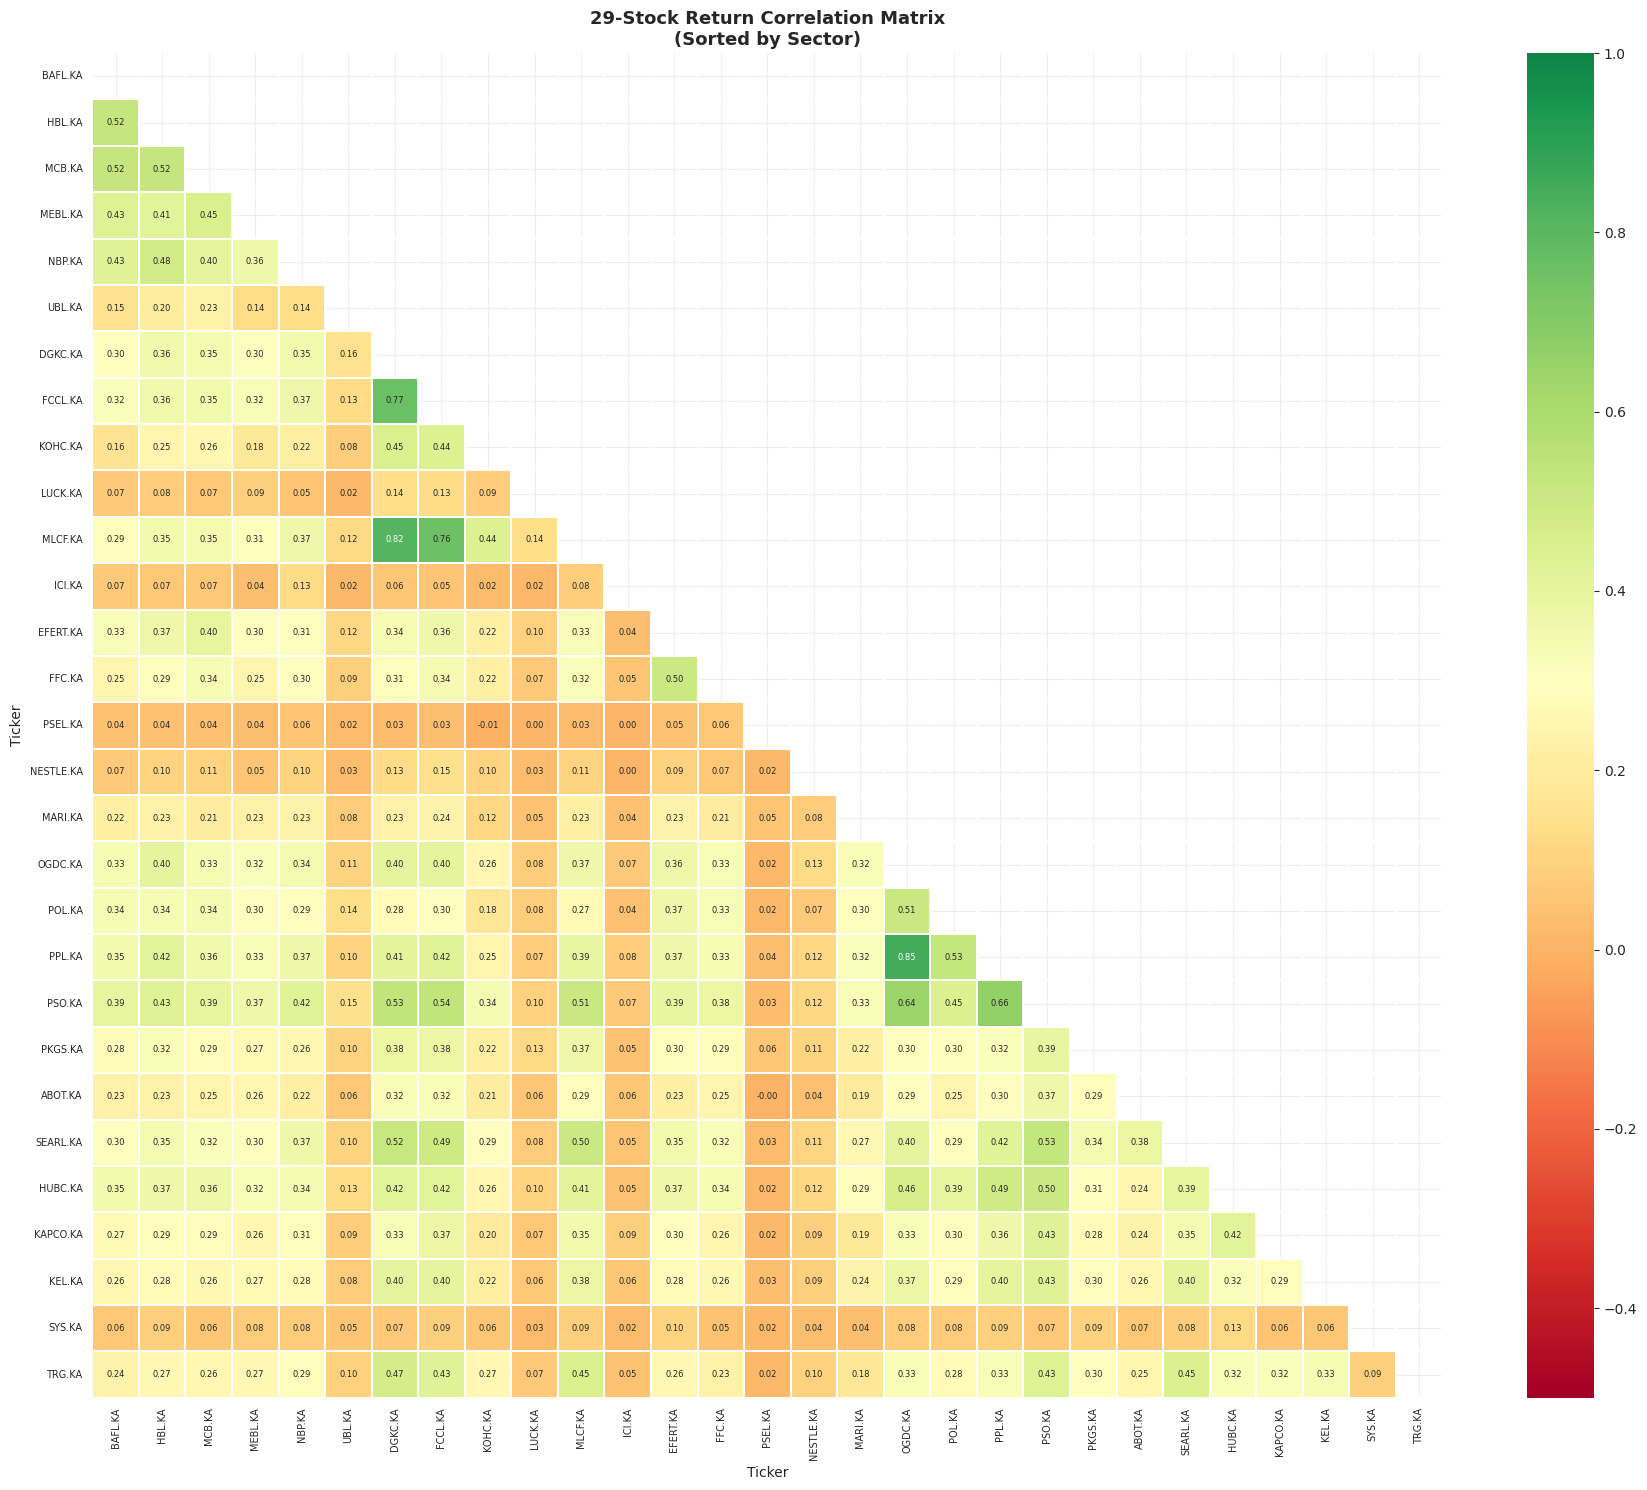

In [9]:
# ── 2.5 Stock Return Correlation Matrix ──────────────────────────────────────
ret_wide = stocks_raw.pivot_table(index='Date', columns='Ticker', values='Return')
corr = ret_wide.corr()

# Sort by sector for visual grouping
sector_order_tickers = sorted(SECTOR_MAP.keys(), key=lambda x: SECTOR_MAP[x])
corr = corr.loc[sector_order_tickers, sector_order_tickers]

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.5, vmax=1, center=0.3, mask=mask,
            linewidths=0.3, ax=ax, annot_kws={'size': 6})
ax.set_title('29-Stock Return Correlation Matrix\n(Sorted by Sector)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

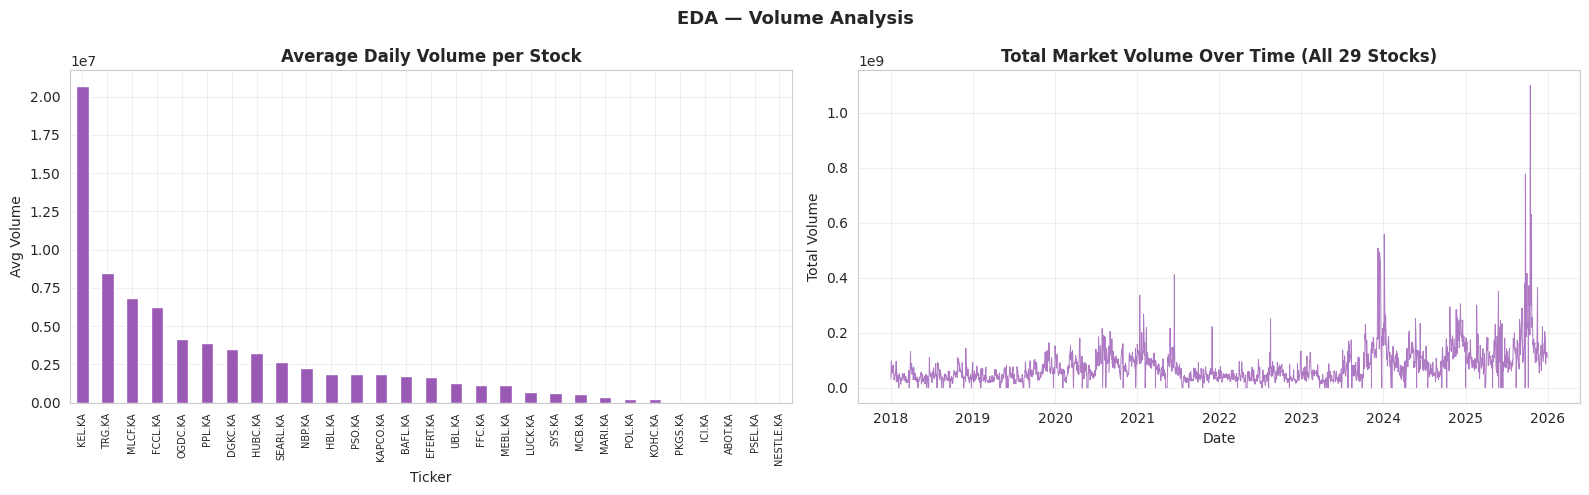

In [10]:
# ── 2.6 Volume Analysis ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average daily volume per stock
avg_vol = stocks_raw.groupby('Ticker')['Volume'].mean().sort_values(ascending=False)
avg_vol.plot(kind='bar', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Average Daily Volume per Stock', fontweight='bold')
axes[0].set_ylabel('Avg Volume')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# Volume over time (market-wide)
total_vol = stocks_raw.groupby('Date')['Volume'].sum()
axes[1].plot(total_vol.index, total_vol.values, color='#9b59b6', linewidth=0.7, alpha=0.8)
axes[1].set_title('Total Market Volume Over Time (All 29 Stocks)', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Volume')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('EDA — Volume Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── 2.7 Outlier Preview — Before Cleaning ─────────────────────────────────────
print('=== Extreme Returns (>20% in a day) — Before Cleaning ===')
extreme = stocks_raw[stocks_raw['Return'].abs() > 0.20][['Ticker','Date','Close','Return']]
extreme = extreme.sort_values('Return')
print(extreme.to_string(index=False))
print(f'\nTotal extreme return events: {len(extreme)}')
print('Note: These are stock split/bonus issue artifacts from Yahoo Finance PSX data.')

print()
print('=== OHLC Violations — Before Cleaning ===')
ohlc_viol = stocks_raw[(stocks_raw['High'] < stocks_raw['Close']) |
                        (stocks_raw['Low'] > stocks_raw['Close'])]
print(f'Total violations: {len(ohlc_viol)}')
print(ohlc_viol.groupby('Ticker').size().sort_values(ascending=False))

=== Extreme Returns (>20% in a day) — Before Cleaning ===
 Ticker       Date       Close    Return
MARI.KA 2024-09-05  367.216919 -0.890436
 SYS.KA 2025-04-09   97.111496 -0.806234
 ICI.KA 2025-07-10  343.609467 -0.800643
 ICI.KA 2025-06-02  295.080627 -0.800524
LUCK.KA 2025-02-26  289.540131 -0.799499
KOHC.KA 2025-08-12   92.206001 -0.798593
LUCK.KA 2025-04-10  317.682434 -0.794766
KOHC.KA 2025-08-18   98.678001 -0.788811
 SYS.KA 2025-05-27  108.820000 -0.595134
 UBL.KA 2025-04-28  225.350555 -0.521891
 SYS.KA 2025-05-19  269.950012 -0.503577
 UBL.KA 2025-06-10  240.726440 -0.500205
 UBL.KA 2025-06-16  242.875412 -0.500000
 UBL.KA 2025-06-24  256.224365 -0.479120
 KEL.KA 2021-09-30    4.000000  0.208459
 KEL.KA 2025-05-26    5.720000  0.211864
 UBL.KA 2025-04-29  445.868286  0.978554
 UBL.KA 2025-06-12  488.162567  1.017178
 UBL.KA 2025-06-19  489.288666  1.021283
 SYS.KA 2025-04-14  502.346924  3.955616
LUCK.KA 2025-03-03 1400.886230  3.959836
 ICI.KA 2025-06-04 1501.627197  3.987680

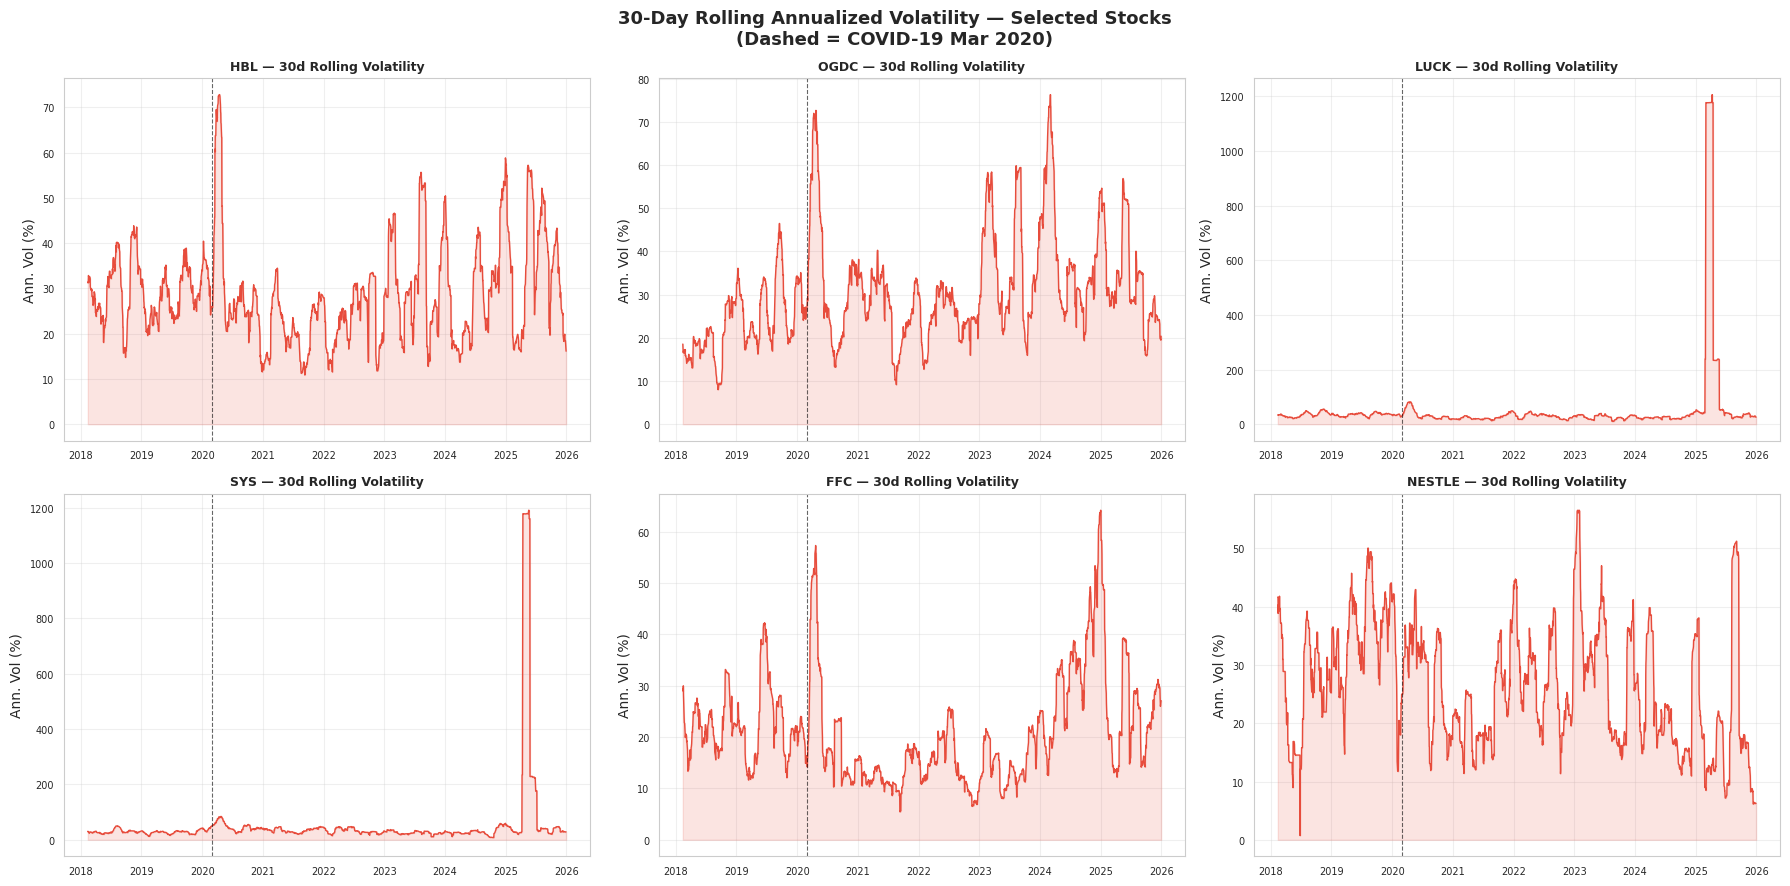

In [12]:
# ── 2.8 Rolling Volatility — Key Stocks ──────────────────────────────────────
highlight = ['HBL.KA', 'OGDC.KA', 'LUCK.KA', 'SYS.KA', 'FFC.KA', 'NESTLE.KA']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, ticker in enumerate(highlight):
    grp = stocks_raw[stocks_raw['Ticker'] == ticker].sort_values('Date')
    roll_vol = grp['Return'].rolling(30).std() * np.sqrt(252) * 100
    axes[i].plot(grp['Date'], roll_vol, color='#e74c3c', linewidth=1)
    axes[i].fill_between(grp['Date'], roll_vol, alpha=0.15, color='#e74c3c')
    axes[i].axvline(pd.Timestamp('2020-03-01'), color='black',
                    linestyle='--', alpha=0.6, linewidth=0.8)
    axes[i].set_title(f'{ticker.replace(".KA","")} — 30d Rolling Volatility',
                      fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Ann. Vol (%)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(labelsize=7)

plt.suptitle('30-Day Rolling Annualized Volatility — Selected Stocks\n(Dashed = COVID-19 Mar 2020)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

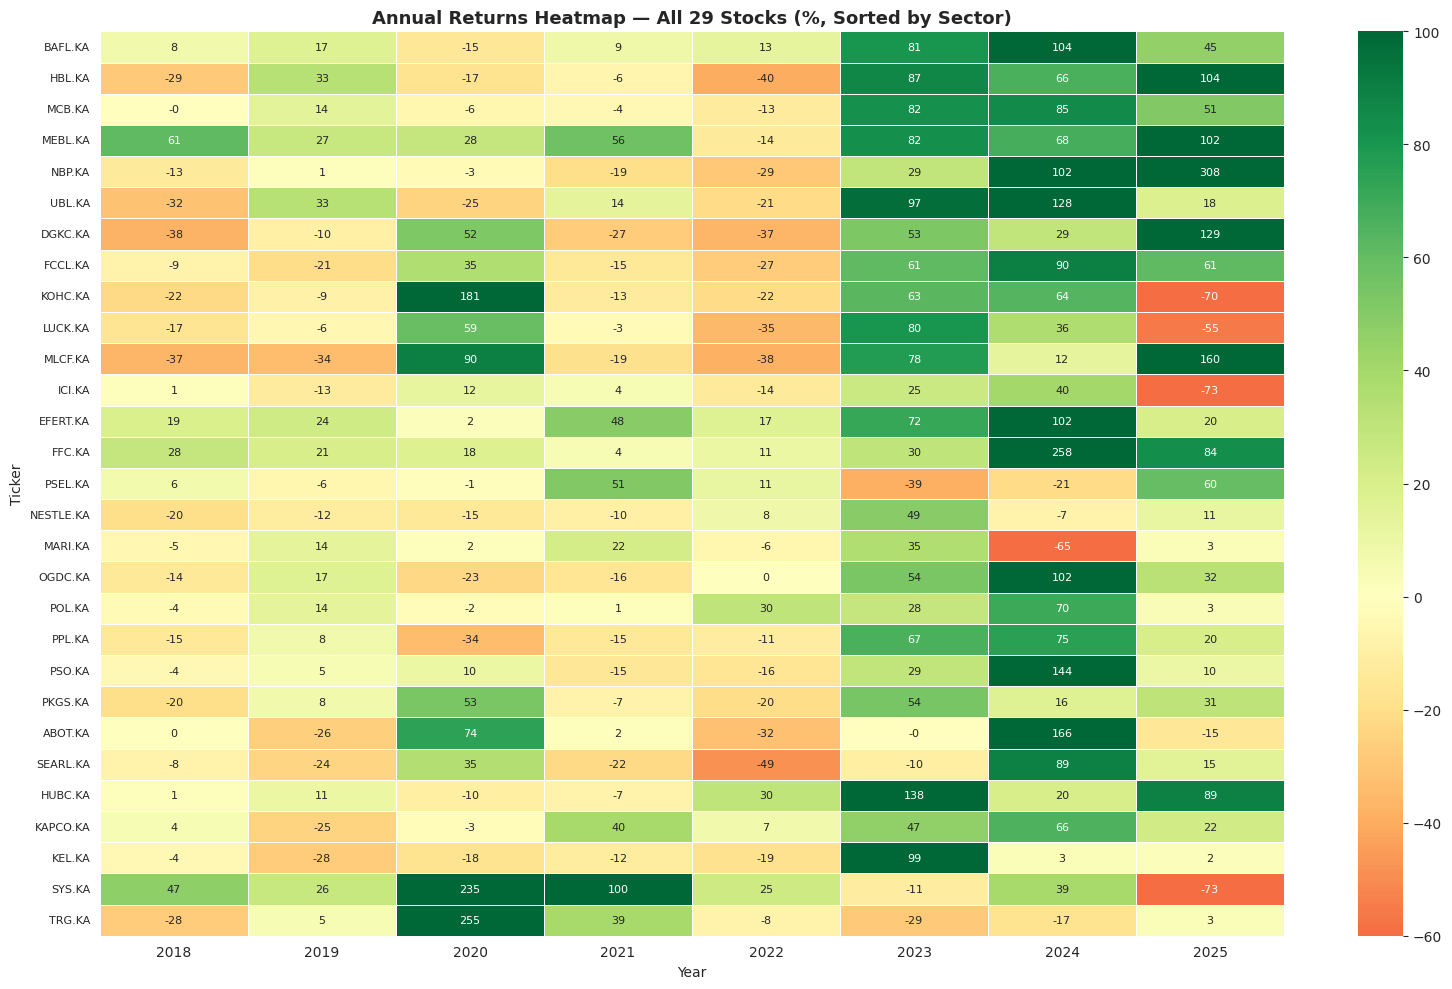

In [13]:
# ── 2.9 Annual Returns Heatmap — All Stocks ───────────────────────────────────
stocks_raw['Year'] = stocks_raw['Date'].dt.year

annual_ret = stocks_raw.groupby(['Ticker','Year']).apply(
    lambda x: (x.sort_values('Date')['Close'].iloc[-1] /
               x.sort_values('Date')['Close'].iloc[0] - 1) * 100
).unstack('Year').round(1)

# Sort by sector
annual_ret = annual_ret.loc[[t for t in sector_order_tickers if t in annual_ret.index]]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(annual_ret, annot=True, fmt='.0f', cmap='RdYlGn',
            center=0, vmin=-60, vmax=100,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Annual Returns Heatmap — All 29 Stocks (%, Sorted by Sector)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

---
## 3. EDA — Sector Benchmarks

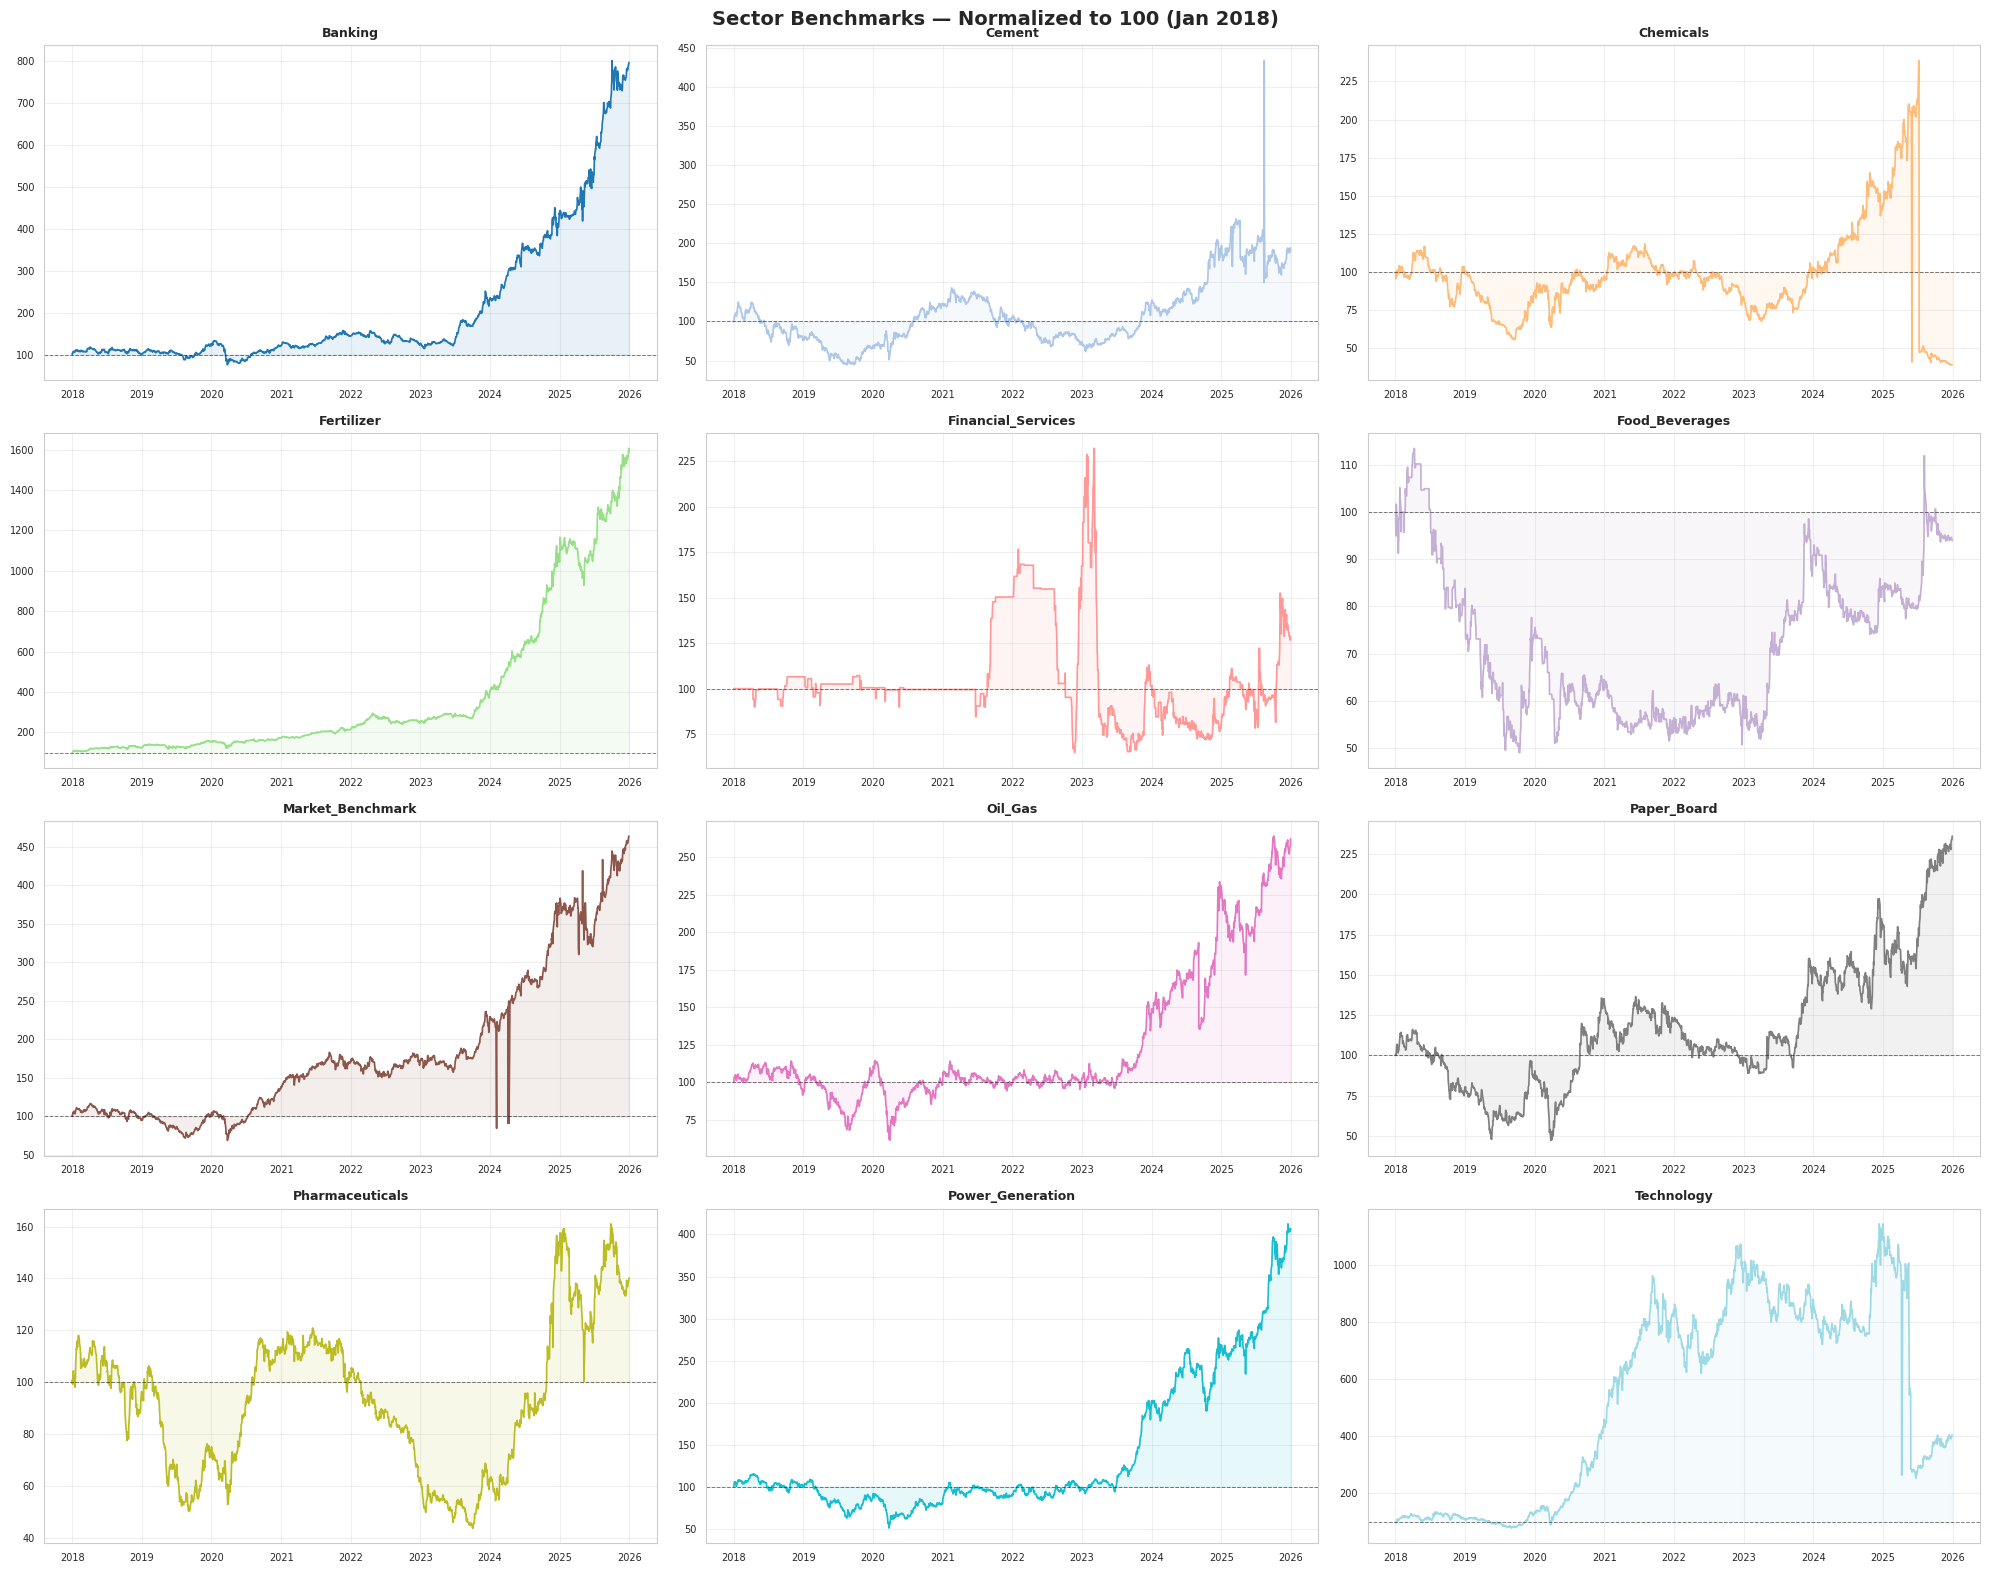

In [14]:
# ── 3.1 Sector Benchmark Trends ───────────────────────────────────────────────
sectors = [c for c in bench_wide.columns if c != 'Date']
fig, axes = plt.subplots(4, 3, figsize=(20, 16))
axes = axes.flatten()
colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))

for i, sector in enumerate(sorted(sectors)):
    grp = bench_wide[['Date', sector]].dropna().sort_values('Date')
    axes[i].plot(grp['Date'], grp[sector], color=colors[i], linewidth=1.2)
    axes[i].fill_between(grp['Date'], grp[sector], 100, alpha=0.1, color=colors[i])
    axes[i].axhline(100, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
    axes[i].set_title(sector, fontsize=9, fontweight='bold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(labelsize=7)

for j in range(len(sectors), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sector Benchmarks — Normalized to 100 (Jan 2018)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

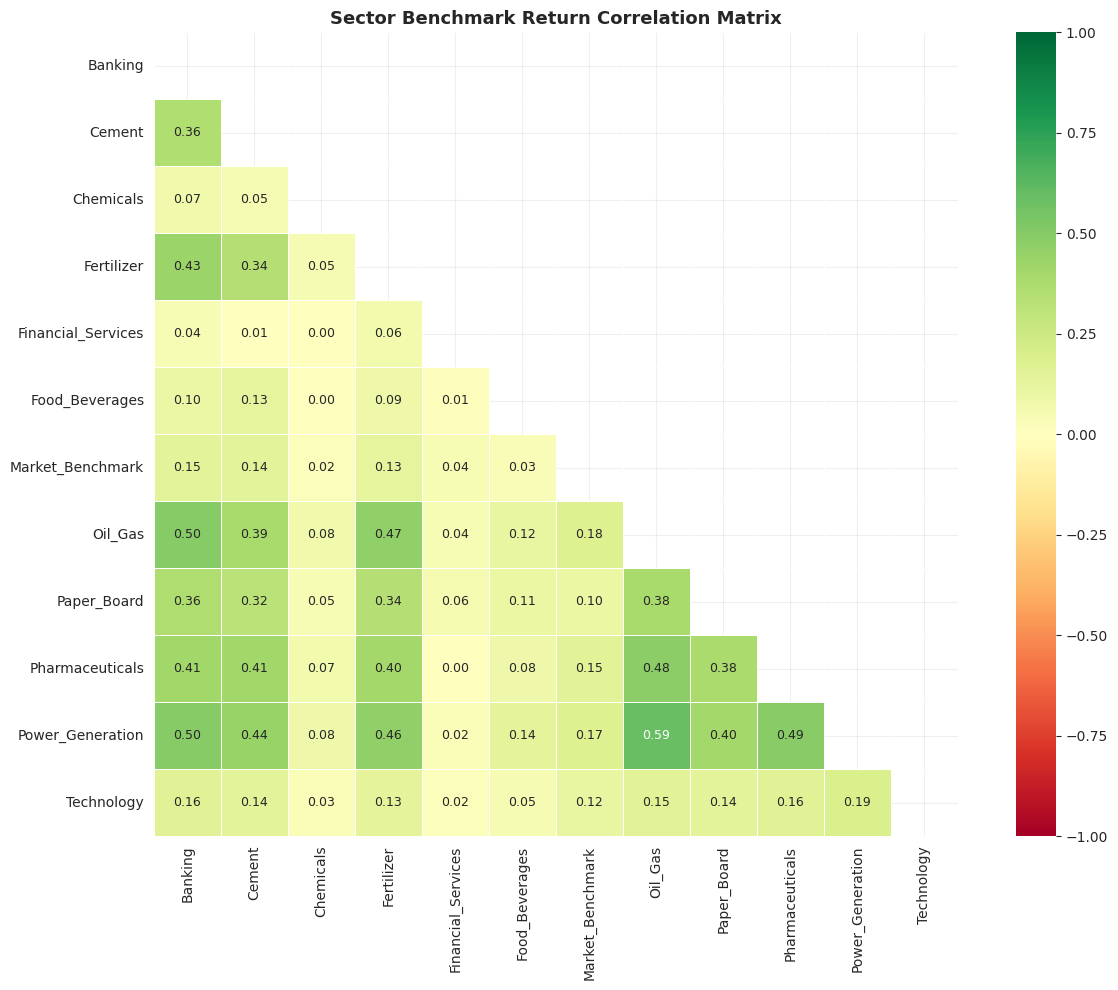

In [15]:
# ── 3.2 Sector Return Correlation Matrix ──────────────────────────────────────
sect_ret_cols = [c for c in sect_returns.columns if c != 'Date']
corr_sect = sect_returns[sect_ret_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_sect, dtype=bool))
sns.heatmap(corr_sect, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, mask=mask,
            linewidths=0.5, ax=ax, square=True, annot_kws={'size': 9})
ax.set_title('Sector Benchmark Return Correlation Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# ── 3.3 Benchmark Missing Values ─────────────────────────────────────────────
print('=== Wide Benchmark Missing Values ===')
missing = bench_wide[sect_ret_cols].isnull().sum().sort_values(ascending=False)
print(missing)
print()
print('Note: Chemicals has 82 missing rows — these are weekend/holiday dates')
print('      where ICI.KA (the only Chemicals stock) had no trading.')
print('      Will be forward-filled in cleaning step.')

=== Wide Benchmark Missing Values ===
Chemicals             82
Fertilizer             6
Power_Generation       6
Oil_Gas                6
Technology             6
Paper_Board            6
Pharmaceuticals        6
Cement                 5
Banking                5
Food_Beverages         3
Financial_Services     2
Market_Benchmark       0
dtype: int64

Note: Chemicals has 82 missing rows — these are weekend/holiday dates
      where ICI.KA (the only Chemicals stock) had no trading.
      Will be forward-filled in cleaning step.


---
## 4. EDA — Cross-Dataset Analysis

In [17]:
# ── 4.1 Date Alignment Check ──────────────────────────────────────────────────
stock_dates = set(stocks_raw['Date'].unique())
bench_dates = set(bench_wide['Date'].unique())
ret_dates   = set(sect_returns['Date'].unique())

print('=== Date Alignment ===')
print(f'Stock dates    : {len(stock_dates)}')
print(f'Benchmark dates: {len(bench_dates)}')
print(f'Returns dates  : {len(ret_dates)}')
print(f'Common (all 3) : {len(stock_dates & bench_dates & ret_dates)}')
print(f'In stocks only : {len(stock_dates - bench_dates)}')
print(f'In bench only  : {len(bench_dates - stock_dates)}')
print()

# Per-stock date count
date_counts = stocks_raw.groupby('Date')['Ticker'].count()
print(f'Days all 29 stocks present : {(date_counts==29).sum()}')
print(f'Days with partial stock data: {(date_counts<29).sum()}')

=== Date Alignment ===
Stock dates    : 2074
Benchmark dates: 2074
Returns dates  : 1991
Common (all 3) : 1991
In stocks only : 0
In bench only  : 0

Days all 29 stocks present : 1992
Days with partial stock data: 82


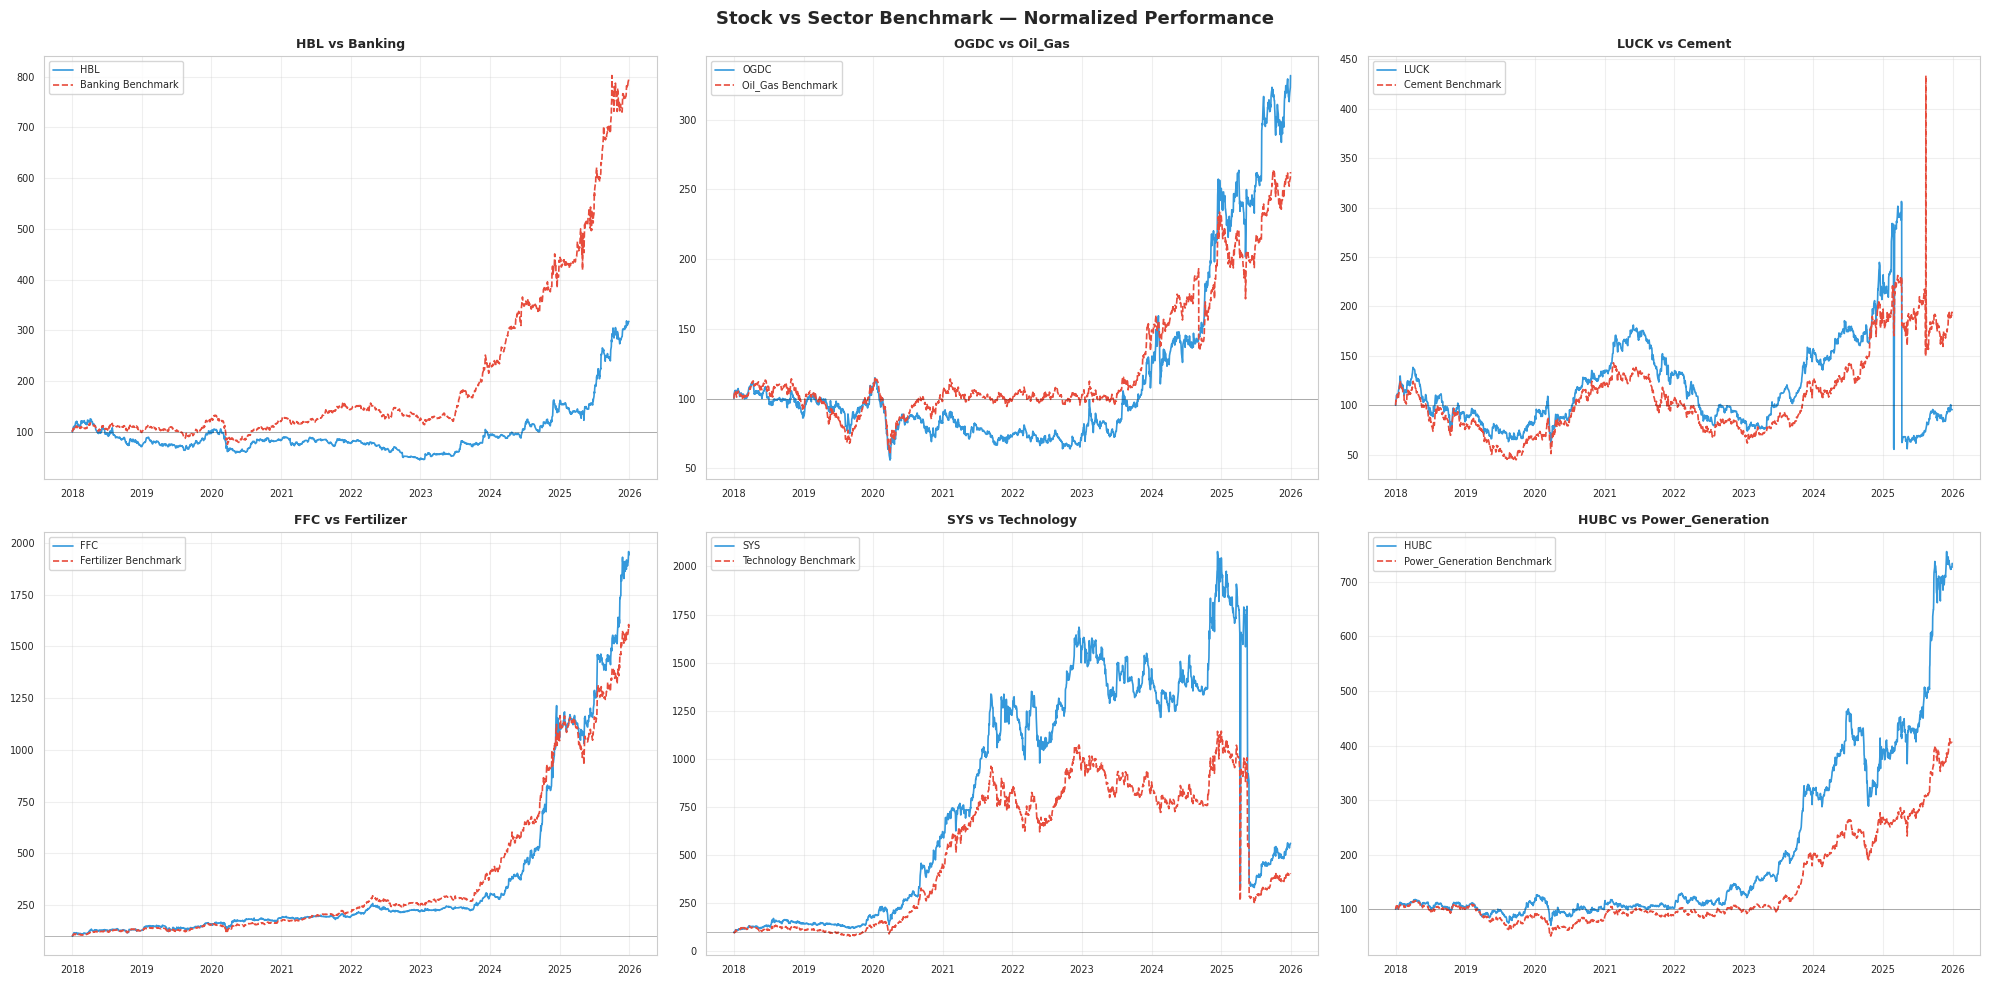

In [18]:
# ── 4.2 Stock vs Sector Benchmark — Visual Comparison ────────────────────────
# Compare each stock return against its sector benchmark
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

# Pick one representative stock per sector (6 most important)
examples = [
    ('HBL.KA', 'Banking'),
    ('OGDC.KA', 'Oil_Gas'),
    ('LUCK.KA', 'Cement'),
    ('FFC.KA', 'Fertilizer'),
    ('SYS.KA', 'Technology'),
    ('HUBC.KA', 'Power_Generation'),
]

for i, (ticker, sector) in enumerate(examples):
    grp = stocks_raw[stocks_raw['Ticker'] == ticker].sort_values('Date')
    stock_norm = grp.set_index('Date')['Close'] / grp['Close'].iloc[0] * 100

    bench_grp = bench_wide[['Date', sector]].dropna().sort_values('Date')
    bench_grp = bench_grp.set_index('Date')[sector]

    axes[i].plot(stock_norm.index, stock_norm.values, color='#3498db',
                 linewidth=1.2, label=ticker.replace('.KA',''))
    axes[i].plot(bench_grp.index, bench_grp.values, color='#e74c3c',
                 linewidth=1.2, linestyle='--', label=f'{sector} Benchmark')
    axes[i].axhline(100, color='black', linewidth=0.5, alpha=0.4)
    axes[i].set_title(f'{ticker.replace(".KA","")} vs {sector}',
                      fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(labelsize=7)

plt.suptitle('Stock vs Sector Benchmark — Normalized Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Data Cleaning

In [19]:
# ── 5.1 Fix OHLC Violations ───────────────────────────────────────────────────
# Where High < Close or Low > Close — clip to fix floating point issues
stocks = stocks_raw.copy()

before = ((stocks['High'] < stocks['Close']) | (stocks['Low'] > stocks['Close'])).sum()

stocks['High'] = stocks[['High', 'Close']].max(axis=1)
stocks['Low']  = stocks[['Low',  'Close']].min(axis=1)

after = ((stocks['High'] < stocks['Close']) | (stocks['Low'] > stocks['Close'])).sum()

print(f'OHLC violations: {before} → {after}')

OHLC violations: 63 → 0


In [20]:
# ── 5.2 IQR Outlier Treatment — Per Stock ────────────────────────────────────
# Applied to returns ONLY (not prices — we never clip raw prices)
# Winsorize extreme returns per stock using IQR method

stocks['Return'] = stocks.groupby('Ticker')['Close'].pct_change()

outlier_report = []
stocks_clean = []

for ticker, grp in stocks.groupby('Ticker'):
    grp = grp.copy().sort_values('Date')
    ret = grp['Return'].dropna()

    Q1, Q3 = ret.quantile(0.25), ret.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_out = ((ret < lower) | (ret > upper)).sum()
    outlier_report.append({'Ticker': ticker, 'Outliers': n_out,
                           'Lower': round(lower,4), 'Upper': round(upper,4)})

    # Winsorize returns — clip Close prices accordingly
    # We flag outlier dates but keep the price (model will learn from log returns)
    grp['Return_Winsorized'] = grp['Return'].clip(lower=lower, upper=upper)
    stocks_clean.append(grp)

stocks_clean = pd.concat(stocks_clean, ignore_index=True)

print('=== IQR Outlier Report — Per Stock ===')
report = pd.DataFrame(outlier_report)
print(report.sort_values('Outliers', ascending=False).to_string(index=False))
print(f'\nTotal outlier return events: {report["Outliers"].sum()}')

=== IQR Outlier Report — Per Stock ===
   Ticker  Outliers   Lower  Upper
  PSEL.KA       646  0.0000 0.0000
NESTLE.KA       548 -0.0141 0.0133
  MARI.KA       217 -0.0281 0.0281
 KAPCO.KA       214 -0.0292 0.0289
  ABOT.KA       204 -0.0319 0.0306
   FFC.KA       195 -0.0228 0.0244
   SYS.KA       181 -0.0386 0.0394
   NBP.KA       177 -0.0379 0.0378
 SEARL.KA       175 -0.0489 0.0471
   UBL.KA       169 -0.0318 0.0329
  OGDC.KA       166 -0.0365 0.0360
 EFERT.KA       165 -0.0256 0.0271
  PKGS.KA       160 -0.0370 0.0366
  MEBL.KA       158 -0.0318 0.0336
   POL.KA       158 -0.0268 0.0273
   HBL.KA       155 -0.0348 0.0343
   TRG.KA       154 -0.0654 0.0668
  HUBC.KA       151 -0.0345 0.0355
   PPL.KA       150 -0.0431 0.0422
   ICI.KA       149 -0.0322 0.0306
  LUCK.KA       147 -0.0397 0.0401
   PSO.KA       147 -0.0428 0.0429
   MCB.KA       147 -0.0272 0.0279
   KEL.KA       146 -0.0540 0.0495
  BAFL.KA       143 -0.0338 0.0342
  KOHC.KA       119 -0.0515 0.0511
  FCCL.KA       

In [21]:
# ── 5.3 Fix Benchmark Missing Values — Forward Fill ──────────────────────────
bench_wide_clean = bench_wide.copy().set_index('Date').sort_index()

before = bench_wide_clean.isnull().sum().sum()
bench_wide_clean = bench_wide_clean.ffill().bfill()
after = bench_wide_clean.isnull().sum().sum()

print(f'Wide benchmark missing: {before} → {after}')

# Same for long format
bench_long_clean = bench_long.copy().sort_values(['Sector','Date'])
bench_long_clean['Close'] = bench_long_clean.groupby('Sector')['Close'].ffill().bfill()
bench_long_clean['Open']  = bench_long_clean.groupby('Sector')['Open'].ffill().bfill()
bench_long_clean['High']  = bench_long_clean.groupby('Sector')['High'].ffill().bfill()
bench_long_clean['Low']   = bench_long_clean.groupby('Sector')['Low'].ffill().bfill()

print(f'Long benchmark missing after fix: {bench_long_clean[["Open","High","Low","Close"]].isnull().sum().sum()}')

Wide benchmark missing: 133 → 0
Long benchmark missing after fix: 0


In [22]:
# ── 5.4 Final Cleaning Verification ──────────────────────────────────────────
print('=== Final Data Quality Check ===')
print()
print(f'Stocks:')
print(f'  Shape          : {stocks_clean.shape}')
print(f'  Missing values : {stocks_clean[["Open","High","Low","Close","Volume"]].isnull().sum().sum()}')
print(f'  OHLC violations: {((stocks_clean["High"]<stocks_clean["Close"])|(stocks_clean["Low"]>stocks_clean["Close"])).sum()}')
print(f'  Stocks         : {stocks_clean["Ticker"].nunique()}')
print()
print(f'Benchmarks (wide):')
print(f'  Shape          : {bench_wide_clean.shape}')
print(f'  Missing values : {bench_wide_clean.isnull().sum().sum()}')
print()
print('All clean ✅')

=== Final Data Quality Check ===

Stocks:
  Shape          : (59905, 12)
  Missing values : 0
  OHLC violations: 0
  Stocks         : 29

Benchmarks (wide):
  Shape          : (2074, 12)
  Missing values : 0

All clean ✅


---
## 6. Feature Engineering

In [23]:
# ── 6.1 Log Returns ───────────────────────────────────────────────────────────
stocks_feat = stocks_clean.copy().sort_values(['Ticker','Date'])

stocks_feat['Log_Return']       = np.log(stocks_feat['Close'] /
                                          stocks_feat.groupby('Ticker')['Close'].shift(1))
stocks_feat['Log_Return_Open']  = np.log(stocks_feat['Open'] /
                                          stocks_feat.groupby('Ticker')['Open'].shift(1))
stocks_feat['Log_Return_High']  = np.log(stocks_feat['High'] /
                                          stocks_feat.groupby('Ticker')['High'].shift(1))
stocks_feat['Log_Return_Low']   = np.log(stocks_feat['Low'] /
                                          stocks_feat.groupby('Ticker')['Low'].shift(1))
stocks_feat['Log_Volume']       = np.log(stocks_feat['Volume'].replace(0, np.nan))

# Add sector benchmark return as a feature
# Merge sector log return into stock data
sect_log_ret = bench_wide_clean.copy()
for col in sect_log_ret.columns:
    sect_log_ret[col] = np.log(sect_log_ret[col] / sect_log_ret[col].shift(1))
sect_log_ret = sect_log_ret.reset_index()

# Map each stock to its sector log return
stocks_feat['Sector_Log_Return'] = stocks_feat.apply(
    lambda row: sect_log_ret.loc[
        sect_log_ret['Date'] == row['Date'], row['Sector']
    ].values[0] if len(sect_log_ret.loc[sect_log_ret['Date']==row['Date'], row['Sector']]) > 0
    else np.nan, axis=1
)

# Relative strength = stock log return - sector log return
stocks_feat['Relative_Strength'] = stocks_feat['Log_Return'] - stocks_feat['Sector_Log_Return']

# Drop first row per stock (NaN from shift)
stocks_feat = stocks_feat.dropna(subset=['Log_Return']).reset_index(drop=True)

print(f'Shape after log return features: {stocks_feat.shape}')
print(f'New features: Log_Return, Log_Return_Open/High/Low, Log_Volume, Sector_Log_Return, Relative_Strength')
print(f'Missing Log_Return: {stocks_feat["Log_Return"].isnull().sum()}')

Shape after log return features: (59876, 19)
New features: Log_Return, Log_Return_Open/High/Low, Log_Volume, Sector_Log_Return, Relative_Strength
Missing Log_Return: 0


In [24]:
# ── 6.2 Min-Max Normalization ─────────────────────────────────────────────────
# Scale OHLCV + return features to [0, 1] per feature across all stocks

SCALE_COLS = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Log_Return', 'Log_Return_Open', 'Log_Return_High',
    'Log_Return_Low', 'Log_Volume',
    'Sector_Log_Return', 'Relative_Strength'
]

# Fill any remaining NaN in scale cols before fitting
stocks_feat[SCALE_COLS] = stocks_feat[SCALE_COLS].fillna(0)

scaler = MinMaxScaler(feature_range=(0, 1))
stocks_scaled = stocks_feat.copy()
stocks_scaled[SCALE_COLS] = scaler.fit_transform(stocks_feat[SCALE_COLS])

# Save scaler
with open('kse30_minmax_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Min-Max scaling applied.')
print('Scaled range check (should all be [0,1]):')
print(stocks_scaled[SCALE_COLS].agg(['min','max']).round(4))

Min-Max scaling applied.
Scaled range check (should all be [0,1]):
     Open  High  Low  Close  Volume  Log_Return  Log_Return_Open  \
min   0.0   0.0  0.0    0.0     0.0         0.0              0.0   
max   1.0   1.0  1.0    1.0     1.0         1.0              1.0   

     Log_Return_High  Log_Return_Low  Log_Volume  Sector_Log_Return  \
min              0.0             0.0         0.0                0.0   
max              1.0             1.0         1.0                1.0   

     Relative_Strength  
min                0.0  
max                1.0  


In [25]:
# ── 6.3 60-Day Sliding Window Readiness ──────────────────────────────────────
WINDOW = 60

print('=== 60-Day Sliding Window Readiness ===')
for ticker, grp in stocks_scaled.groupby('Ticker'):
    n = len(grp)
    windows = n - WINDOW
    print(f'  {ticker:<12} {n} rows → {windows} windows')

total_windows = sum(len(g) - WINDOW for _, g in stocks_scaled.groupby('Ticker'))
print(f'\nTotal training windows across all stocks: {total_windows:,}')

=== 60-Day Sliding Window Readiness ===
  ABOT.KA      2067 rows → 2007 windows
  BAFL.KA      2067 rows → 2007 windows
  DGKC.KA      2067 rows → 2007 windows
  EFERT.KA     2067 rows → 2007 windows
  FCCL.KA      2067 rows → 2007 windows
  FFC.KA       2067 rows → 2007 windows
  HBL.KA       2067 rows → 2007 windows
  HUBC.KA      2067 rows → 2007 windows
  ICI.KA       1991 rows → 1931 windows
  KAPCO.KA     2067 rows → 2007 windows
  KEL.KA       2067 rows → 2007 windows
  KOHC.KA      2068 rows → 2008 windows
  LUCK.KA      2067 rows → 2007 windows
  MARI.KA      2067 rows → 2007 windows
  MCB.KA       2067 rows → 2007 windows
  MEBL.KA      2067 rows → 2007 windows
  MLCF.KA      2067 rows → 2007 windows
  NBP.KA       2067 rows → 2007 windows
  NESTLE.KA    2070 rows → 2010 windows
  OGDC.KA      2067 rows → 2007 windows
  PKGS.KA      2067 rows → 2007 windows
  POL.KA       2067 rows → 2007 windows
  PPL.KA       2067 rows → 2007 windows
  PSEL.KA      2071 rows → 2011 windows


---
## 7. Save All Clean Files

In [27]:
# Save all output files
stocks_feat.to_csv('KSE30_stocks_clean.csv', index=False)
stocks_scaled.to_csv('KSE30_stocks_clean_scaled.csv', index=False)
bench_wide_clean.to_csv('KSE30_benchmarks_clean_wide.csv')
bench_long_clean.to_csv('KSE30_benchmarks_clean_long.csv', index=False)

print('Files saved:')
print('  KSE30_stocks_clean.csv          — cleaned stocks, unscaled (use for technical indicators)')
print('  KSE30_stocks_clean_scaled.csv   — cleaned stocks, min-max normalized')
print('  KSE30_benchmarks_clean_wide.csv — clean sector benchmarks, wide format')
print('  KSE30_benchmarks_clean_long.csv — clean sector benchmarks, long format')
print('  kse30_minmax_scaler.pkl         — scaler for inverse transform at prediction')

from google.colab import files
files.download('KSE30_stocks_clean.csv')
files.download('KSE30_stocks_clean_scaled.csv')
files.download('KSE30_benchmarks_clean_wide.csv')
files.download('KSE30_benchmarks_clean_long.csv')
files.download('kse30_minmax_scaler.pkl')

Files saved:
  KSE30_stocks_clean.csv          — cleaned stocks, unscaled (use for technical indicators)
  KSE30_stocks_clean_scaled.csv   — cleaned stocks, min-max normalized
  KSE30_benchmarks_clean_wide.csv — clean sector benchmarks, wide format
  KSE30_benchmarks_clean_long.csv — clean sector benchmarks, long format
  kse30_minmax_scaler.pkl         — scaler for inverse transform at prediction


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# Final summary
print('='*60)
print('  PREPROCESSING COMPLETE — SUMMARY')
print('='*60)
print(f'  Stocks              : 29 KSE-30 constituents (ENGRO dropped)')
print(f'  Date range          : 2018-01-01 → 2025-12-30')
print(f'  Stock rows          : {len(stocks_scaled):,}')
print(f'  Sectors             : 11 + Market Benchmark = 12')
print(f'  Missing values      : 0')
print(f'  OHLC violations     : 0')
print(f'  Features per row    : {len(SCALE_COLS)} scaled + metadata')
print(f'  Total 60d windows   : {total_windows:,}')
print()
print('  Steps completed:')
print('  ✅ OHLC violation fix (High/Low clipped to Close)')
print('  ✅ IQR outlier Winsorization per stock')
print('  ✅ Benchmark forward-fill (82 missing → 0)')
print('  ✅ Log returns (Close, OHLC, Volume)')
print('  ✅ Sector log return merged per stock')
print('  ✅ Relative strength feature added')
print('  ✅ Min-Max normalization [0,1]')
print('  ✅ 60-day window readiness confirmed')
print()
print('  Next → Feature Engineering (RSI, MACD, Bollinger Bands, Momentum)')
print('='*60)

  PREPROCESSING COMPLETE — SUMMARY
  Stocks              : 29 KSE-30 constituents (ENGRO dropped)
  Date range          : 2018-01-01 → 2025-12-30
  Stock rows          : 59,876
  Sectors             : 11 + Market Benchmark = 12
  Missing values      : 0
  OHLC violations     : 0
  Features per row    : 12 scaled + metadata
  Total 60d windows   : 58,136

  Steps completed:
  ✅ OHLC violation fix (High/Low clipped to Close)
  ✅ IQR outlier Winsorization per stock
  ✅ Benchmark forward-fill (82 missing → 0)
  ✅ Log returns (Close, OHLC, Volume)
  ✅ Sector log return merged per stock
  ✅ Relative strength feature added
  ✅ Min-Max normalization [0,1]
  ✅ 60-day window readiness confirmed

  Next → Feature Engineering (RSI, MACD, Bollinger Bands, Momentum)


---
## ✅ Preprocessing Complete

| File | Purpose |
|---|---|
| `KSE30_stocks_clean.csv` | Unscaled clean data — use for technical indicator computation |
| `KSE30_stocks_clean_scaled.csv` | Scaled [0,1] — use as model input |
| `KSE30_benchmarks_clean_wide.csv` | Clean sector benchmarks — use for Black-Litterman prior |
| `KSE30_benchmarks_clean_long.csv` | Long format benchmarks — use for sector-level analysis |
| `kse30_minmax_scaler.pkl` | Saved scaler — use for inverse transform at prediction time |

**Next notebook → Feature Engineering:** RSI, MACD, Bollinger Bands, Momentum (3/6/12m), Volatility, Rate-of-Change, then CFS + RFE feature selection.